In [1]:
import pandas as pd
import os

In [2]:
seed = 42

DIR_RAW = './dataset_raw'
DIR_SPLIT_OUT = './dataset_split'

dataset_name_dir = 'real_NCT00981058_inject'

In [3]:
df_features = pd.read_csv(os.path.join(DIR_RAW, dataset_name_dir,'df_features.csv'), index_col=0)
df_features = df_features.set_index('subject')
cols_feats = df_features.columns
n_unique_val_per_col = df_features.nunique()
col_numer = n_unique_val_per_col.index[n_unique_val_per_col > 5]
col_cat = [i for i in df_features.columns if i not in col_numer and i != 'subject']
df_features = df_features.reset_index()

df_event_time = pd.read_csv(os.path.join(DIR_RAW, dataset_name_dir,'df_state_history_sampled_max.csv'),  index_col=0)
df_event_time = df_event_time.rename(columns={'SUBJID':'subject'})

In [4]:
df_features.head()

,subject,feat__AGE,feat__BLOOD AND LYMPHATIC SYSTEM DISORDERS,feat__BMIBL,feat__BSABL,feat__Body Surface Area (m^2),feat__CARDIAC DISORDERS,"feat__CONGENITAL, FAMILIAL AND GENETIC DISORDERS",feat__Diastolic Blood Pressure (mmHg),feat__EAR AND LABYRINTH DISORDERS,...,feat__SMKB_Non Smoker (fewer than 100 cigarettes lifetime),feat__SMKB_Smoker (all others),feat__SOCIAL CIRCUMSTANCES,feat__SURGICAL AND MEDICAL PROCEDURES,feat__Systolic Blood Pressure (mmHg),feat__Temperature (°C),feat__VASCULAR DISORDERS,"feat__WBCCAT1_> 11,000 µl (11 x 10^9/L)",feat__Weight (kg),feat__traj_clust
0,b'001-7881',58.0,1.0,19.378720,1.60,1.60,0.0,0.0,80.0,1.0,...,0.0,1.0,0.0,0.0,120.0,36.3,2.0,1.0,53.5,0.0
1,b'001-7882',56.0,2.0,20.370370,1.83,1.83,0.0,0.0,60.0,0.0,...,0.0,1.0,0.0,2.0,100.0,36.1,0.0,0.0,65.5,1.0
2,b'006-7880',68.0,2.0,23.060797,1.56,1.56,0.0,0.0,89.0,0.0,...,0.0,1.0,0.0,1.0,108.0,36.7,1.0,1.0,55.0,1.0
3,b'008-7881',59.0,0.0,24.801587,1.80,1.80,0.0,1.0,60.0,0.0,...,0.0,1.0,0.0,0.0,105.0,35.7,0.0,1.0,70.0,2.0
4,b'011-7808',62.0,2.0,23.108435,1.76,1.76,0.0,0.0,72.0,0.0,...,0.0,1.0,0.0,1.0,102.0,37.5,2.0,1.0,66.0,1.0


In [5]:
df_event_time.head()

,subject,t,g_max_by_time
0,b'001-7881',0.0,0.0
1,b'001-7881',15.0,2.0
2,b'001-7881',30.0,2.0
0,b'001-7882',0.0,0.0
1,b'001-7882',2.0,2.0


In [6]:
def summarize_event_times(df):
    out = dict()
    out['max_grade'] = df['g_max_by_time'].max()
    out['time_to_max_grade'] = df.loc[
        df['g_max_by_time'] == out['max_grade'],
        't'
    ].min()//30
    out['time_last_obs'] = df['t'].max()//30
    return pd.Series(out)
df_event_time_summary = df_event_time.groupby('subject').apply(summarize_event_times)
df_event_time_summary = df_event_time_summary.reset_index()
df_event_time_summary

/tmp/ipykernel_15577/4180477579.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_event_time_summary = df_event_time.groupby('subject').apply(summarize_event_times)


,subject,max_grade,time_to_max_grade,time_last_obs
0,b'001-7881',2.0,0.0,1.0
1,b'001-7882',4.0,0.0,4.0
2,b'006-7880',4.0,0.0,4.0
3,b'008-7881',1.0,0.0,2.0
4,b'011-7808',3.0,0.0,3.0
...,...,...,...,...
516,b'780-7886',1.0,0.0,0.0
517,b'782-7881',3.0,0.0,1.0
518,b'782-7886',2.0,0.0,0.0
519,b'981-7880',3.0,1.0,4.0


In [7]:
df_for_splitting = df_features.merge(df_event_time_summary, on='subject', how='left')
assert df_for_splitting.shape[0] == df_features.shape[0]

In [8]:
df_features.head()

,subject,feat__AGE,feat__BLOOD AND LYMPHATIC SYSTEM DISORDERS,feat__BMIBL,feat__BSABL,feat__Body Surface Area (m^2),feat__CARDIAC DISORDERS,"feat__CONGENITAL, FAMILIAL AND GENETIC DISORDERS",feat__Diastolic Blood Pressure (mmHg),feat__EAR AND LABYRINTH DISORDERS,...,feat__SMKB_Non Smoker (fewer than 100 cigarettes lifetime),feat__SMKB_Smoker (all others),feat__SOCIAL CIRCUMSTANCES,feat__SURGICAL AND MEDICAL PROCEDURES,feat__Systolic Blood Pressure (mmHg),feat__Temperature (°C),feat__VASCULAR DISORDERS,"feat__WBCCAT1_> 11,000 µl (11 x 10^9/L)",feat__Weight (kg),feat__traj_clust
0,b'001-7881',58.0,1.0,19.378720,1.60,1.60,0.0,0.0,80.0,1.0,...,0.0,1.0,0.0,0.0,120.0,36.3,2.0,1.0,53.5,0.0
1,b'001-7882',56.0,2.0,20.370370,1.83,1.83,0.0,0.0,60.0,0.0,...,0.0,1.0,0.0,2.0,100.0,36.1,0.0,0.0,65.5,1.0
2,b'006-7880',68.0,2.0,23.060797,1.56,1.56,0.0,0.0,89.0,0.0,...,0.0,1.0,0.0,1.0,108.0,36.7,1.0,1.0,55.0,1.0
3,b'008-7881',59.0,0.0,24.801587,1.80,1.80,0.0,1.0,60.0,0.0,...,0.0,1.0,0.0,0.0,105.0,35.7,0.0,1.0,70.0,2.0
4,b'011-7808',62.0,2.0,23.108435,1.76,1.76,0.0,0.0,72.0,0.0,...,0.0,1.0,0.0,1.0,102.0,37.5,2.0,1.0,66.0,1.0


In [9]:
cols_strat = col_cat + [i for i in df_event_time_summary.columns if i !='subject']
def get_sampling_prob(df):
    df_out = df[['subject']].copy()
    df_out['sampling_prob'] = df[cols_strat].shape[0]/df_features.shape[0]
    return df_out
sampling_weight = df_for_splitting.groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)
sampling_weight['sampling_prob'] = sampling_weight['sampling_prob']/sampling_weight['sampling_prob'].sum()
sampling_weight = sampling_weight.set_index('subject')

/tmp/ipykernel_15577/888579587.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampling_weight = df_for_splitting.groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)


In [10]:
import numpy as np
subj_all = list(sampling_weight.index)
np.random.seed(seed=seed)
subj_test = np.random.choice(sampling_weight.index, size=100, replace=False, p=sampling_weight['sampling_prob'])

sampling_weight = df_for_splitting.loc[
    ~df_for_splitting['subject'].isin(subj_test),:
].groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)
sampling_weight['sampling_prob'] = sampling_weight['sampling_prob']/sampling_weight['sampling_prob'].sum()
sampling_weight = sampling_weight.set_index('subject')

np.random.seed(seed=seed)
subj_val= np.random.choice(sampling_weight.index, size=100, replace=False, p=sampling_weight['sampling_prob'])
subj_train = [i for i in subj_all if (i not in subj_val) and (i not in subj_test)]


np.random.seed(seed=seed)
sampling_weight = df_for_splitting.loc[
    df_for_splitting['subject'].isin(subj_train),:
].groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)
sampling_weight['sampling_prob'] = sampling_weight['sampling_prob']/sampling_weight['sampling_prob'].sum()
sampling_weight = sampling_weight.set_index('subject')
subj_train_tune = np.random.choice(sampling_weight.index, size=len(subj_train)//2, replace=False, p=sampling_weight['sampling_prob'])



/tmp/ipykernel_15577/312921327.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ].groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)
/tmp/ipykernel_15577/312921327.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ].groupby(cols_strat).apply(get_sampling_prob).reset_index(drop=True)


In [11]:


df_features_train_test_val = df_features.copy()
df_features_train_test_val['split'] = None
df_features_train_test_val.loc[df_features_train_test_val['subject'].isin(subj_train), 'split'] = 'train'
df_features_train_test_val.loc[df_features_train_test_val['subject'].isin(subj_val), 'split'] = 'val'
df_features_train_test_val.loc[df_features_train_test_val['subject'].isin(subj_test), 'split'] = 'test'

df_y_train_test_val = df_event_time.copy()
df_y_train_test_val['split'] = None
df_y_train_test_val.loc[df_y_train_test_val['subject'].isin(subj_train), 'split'] = 'train'
df_y_train_test_val.loc[df_y_train_test_val['subject'].isin(subj_val), 'split'] = 'val'
df_y_train_test_val.loc[df_y_train_test_val['subject'].isin(subj_test), 'split'] = 'test'

In [12]:
df_y_train_test_val

,subject,t,g_max_by_time,split
0,b'001-7881',0.0,0.0,val
1,b'001-7881',15.0,2.0,val
2,b'001-7881',30.0,2.0,val
0,b'001-7882',0.0,0.0,train
1,b'001-7882',2.0,2.0,train
...,...,...,...,...
6,b'981-7886',63.0,3.0,train
7,b'981-7886',78.0,3.0,train
8,b'981-7886',90.0,3.0,train
9,b'981-7886',98.0,3.0,train


<Axes: xlabel='g_max_by_time', ylabel='t'>

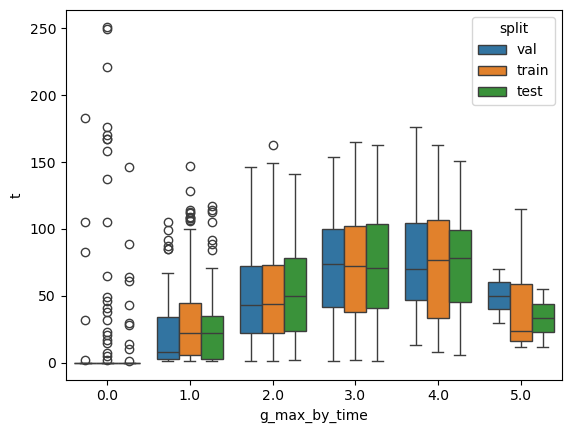

In [13]:
import seaborn as sns
sns.boxplot(
    data=df_y_train_test_val,
    y='t',
    x='g_max_by_time',
    hue='split',
)

In [14]:
df_features_train_test_val['split'].value_counts(normalize=True)

split
train    0.616123
val      0.191939
test     0.191939
Name: proportion, dtype: float64

In [15]:
df_features_train_test_val['split'].value_counts(normalize=False)

split
train    321
val      100
test     100
Name: count, dtype: int64

/tmp/ipykernel_15577/691614602.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,1, figsize=(3,4))


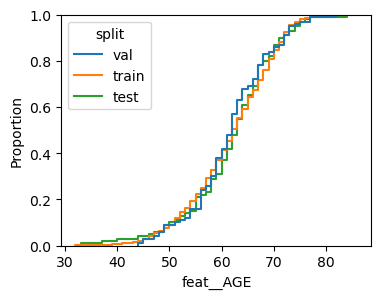

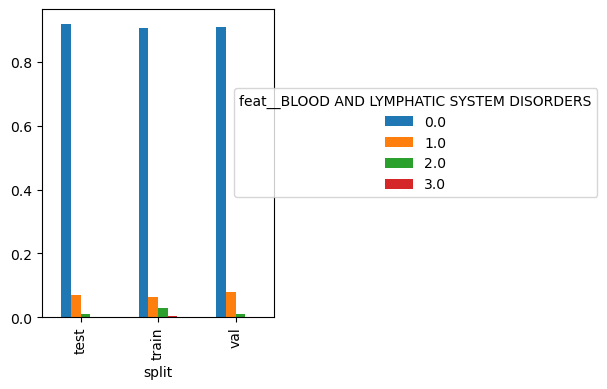

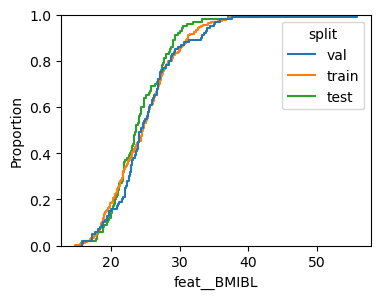

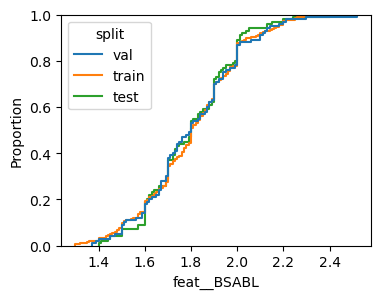

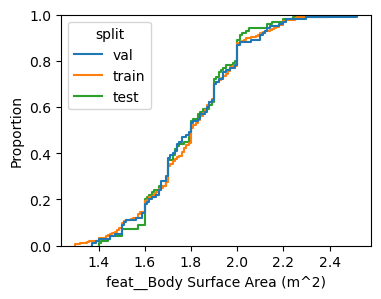

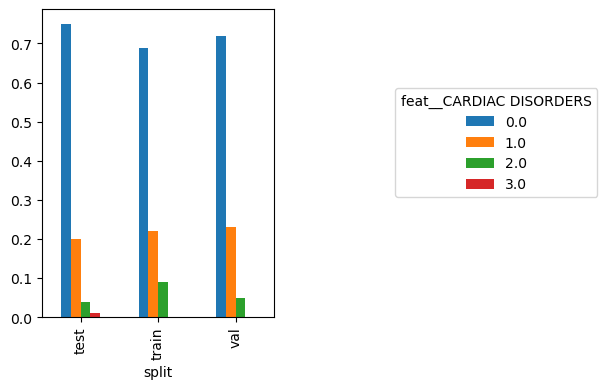

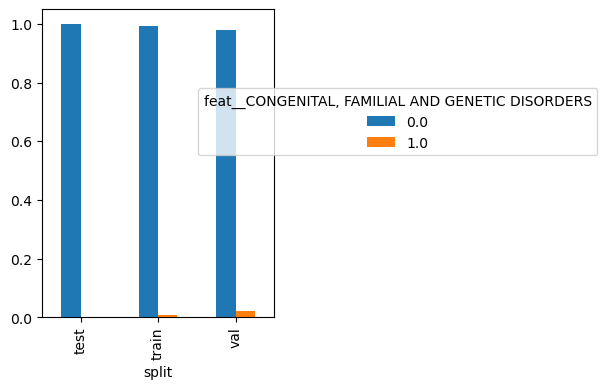

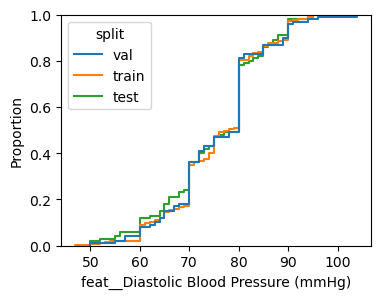

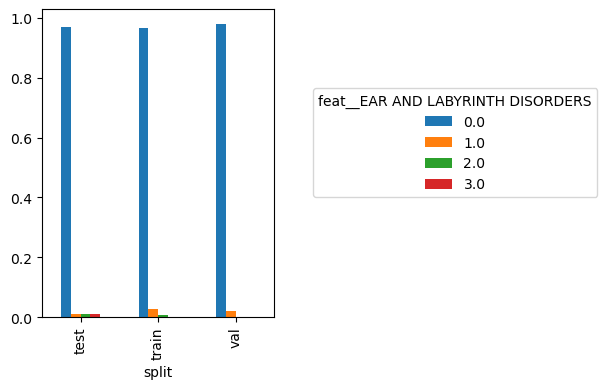

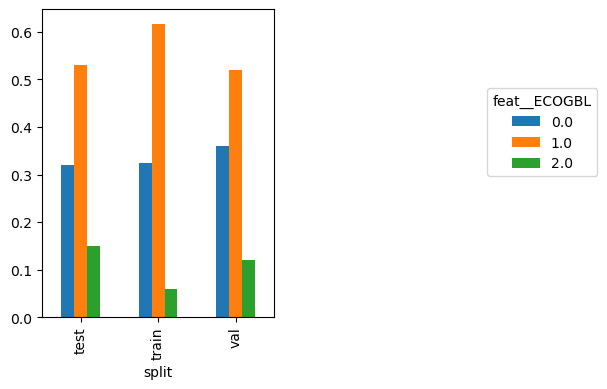

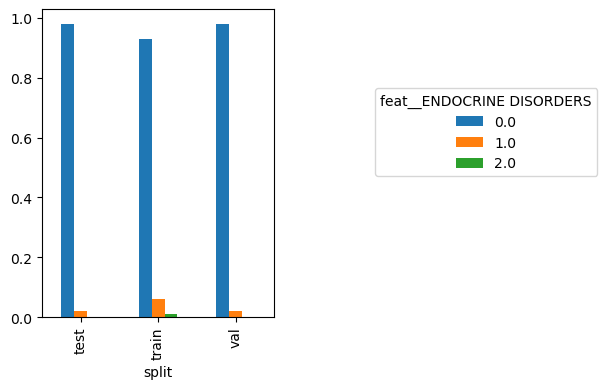

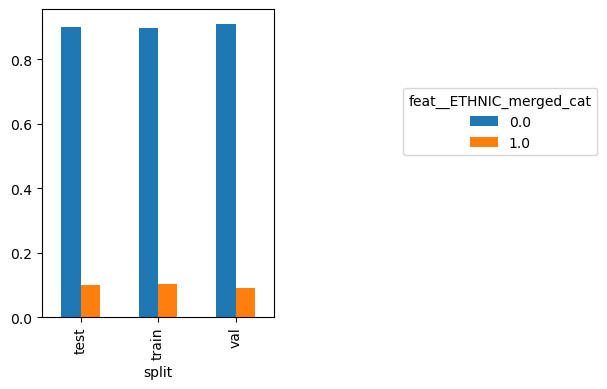

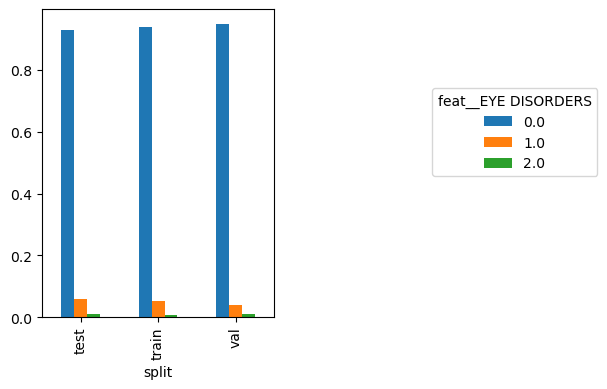

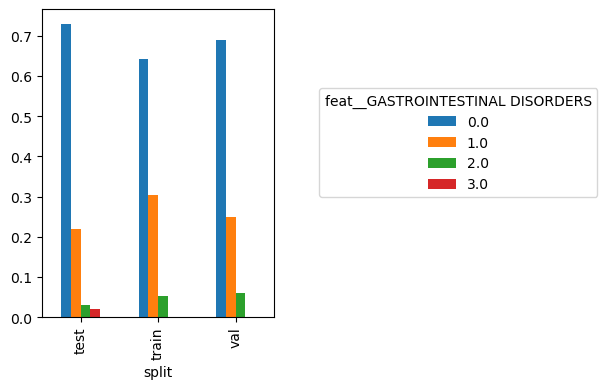

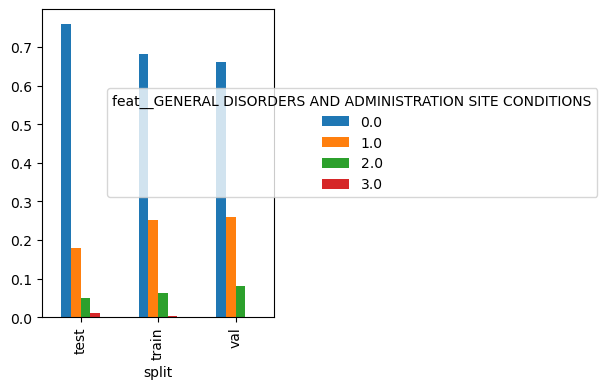

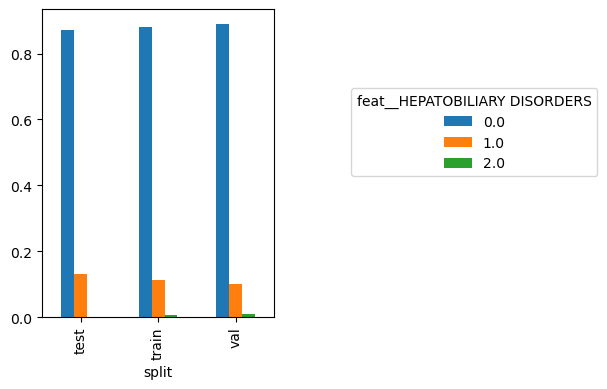

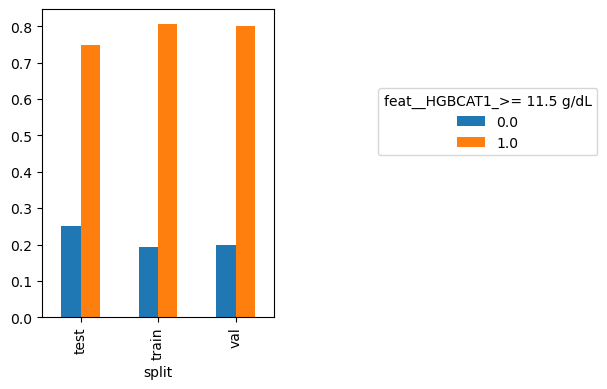

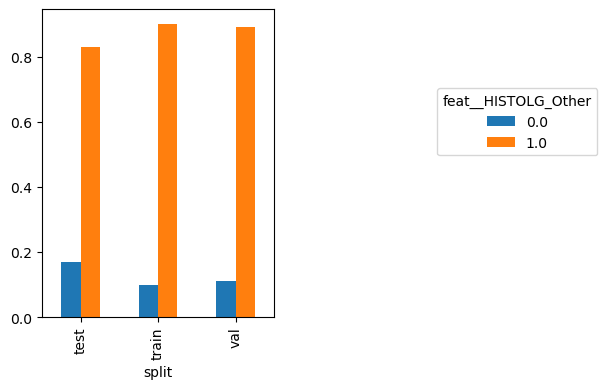

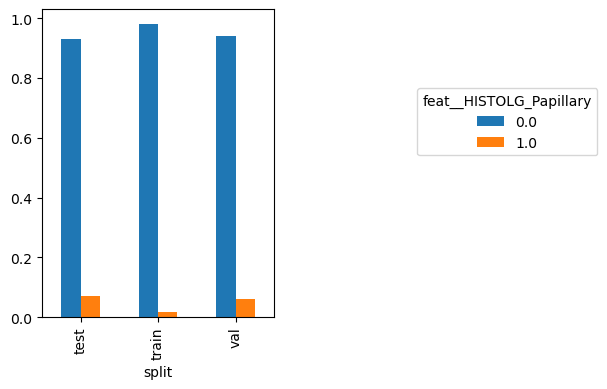

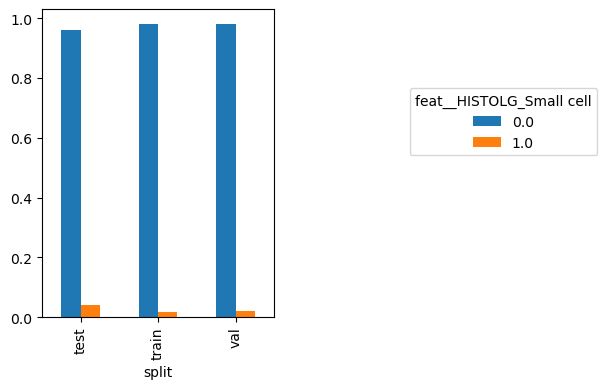

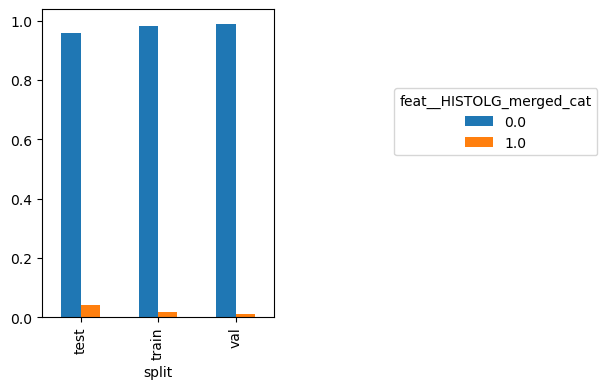

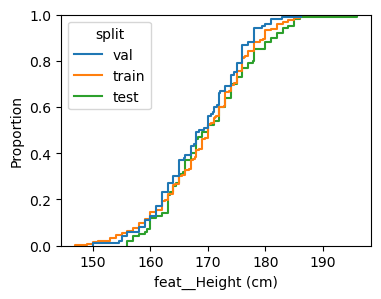

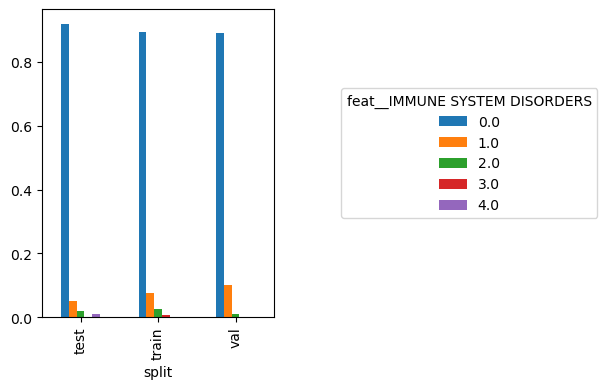

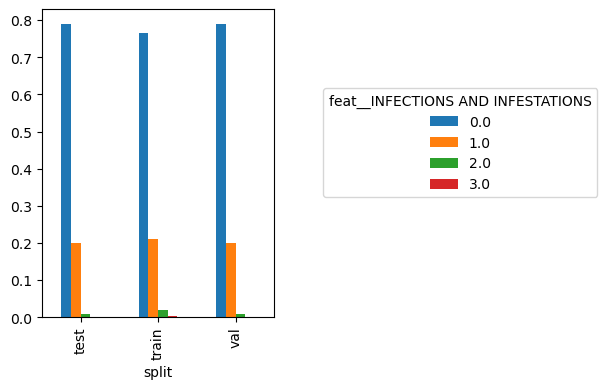

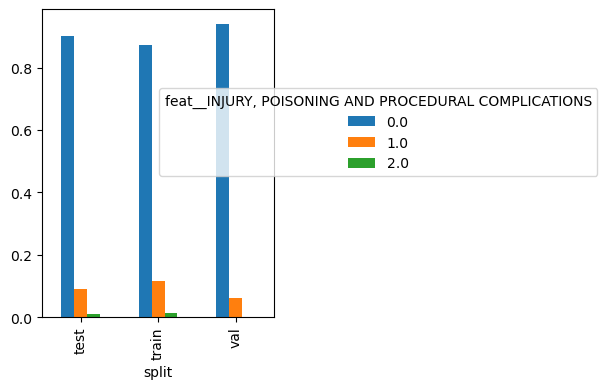

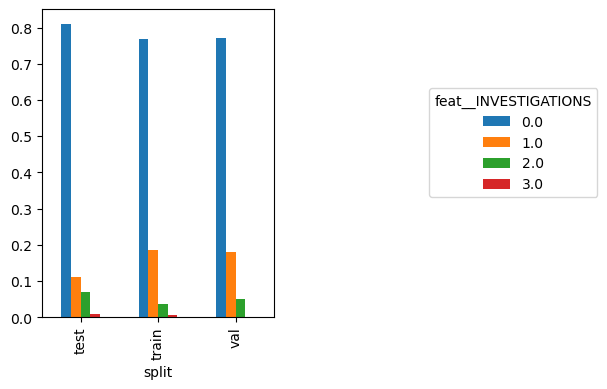

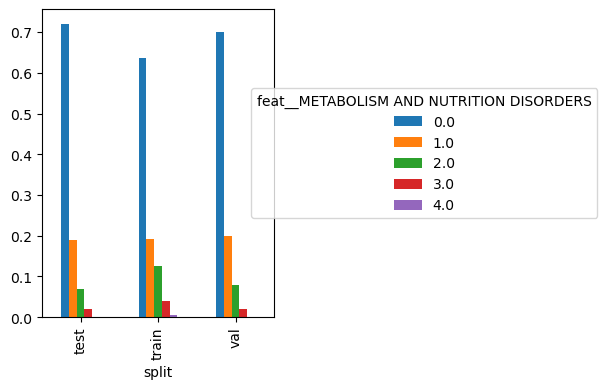

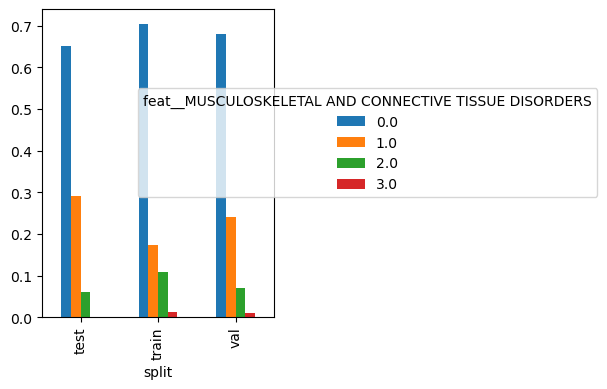

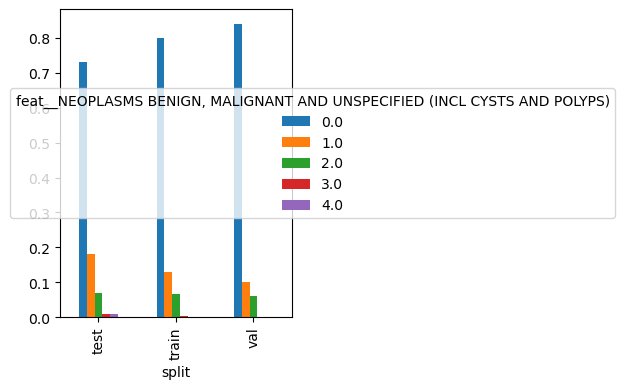

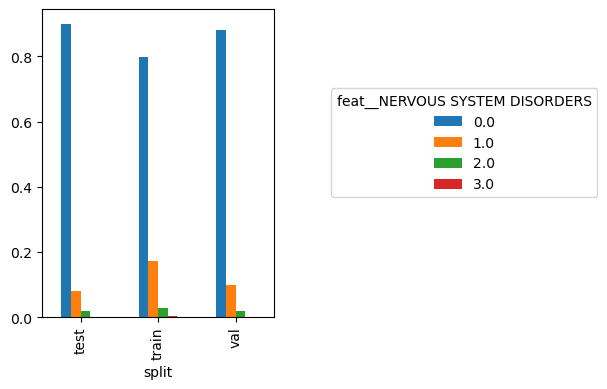

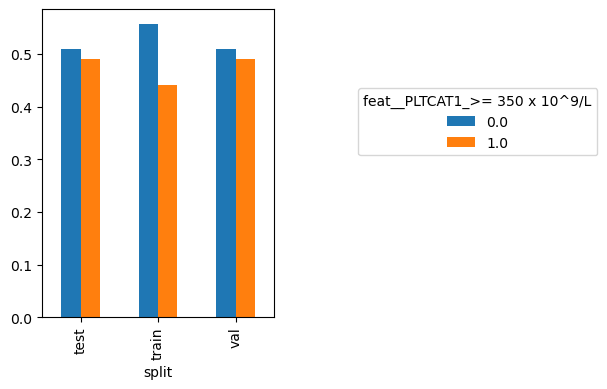

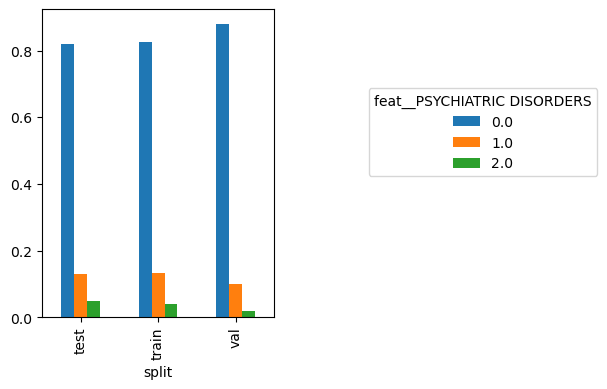

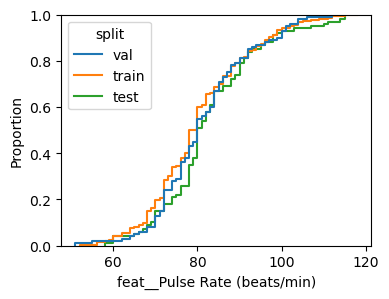

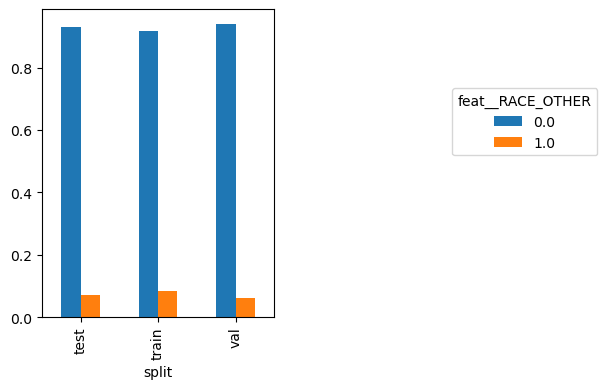

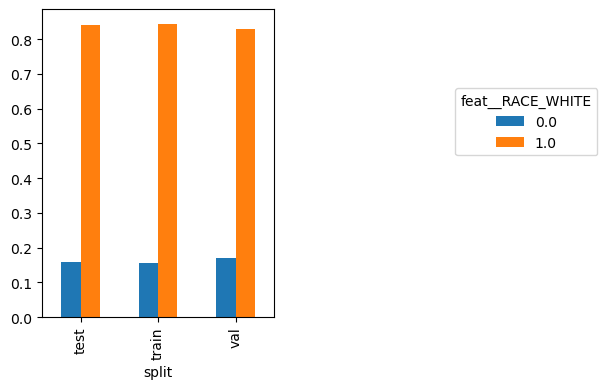

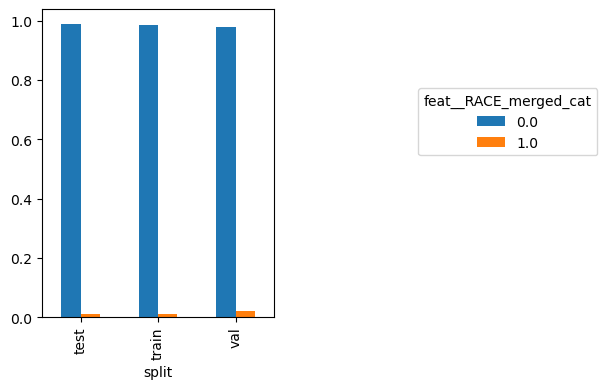

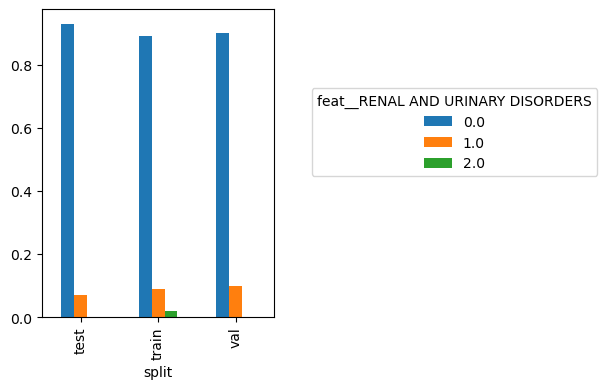

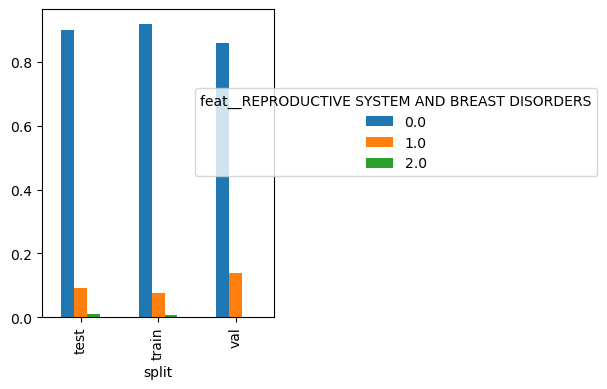

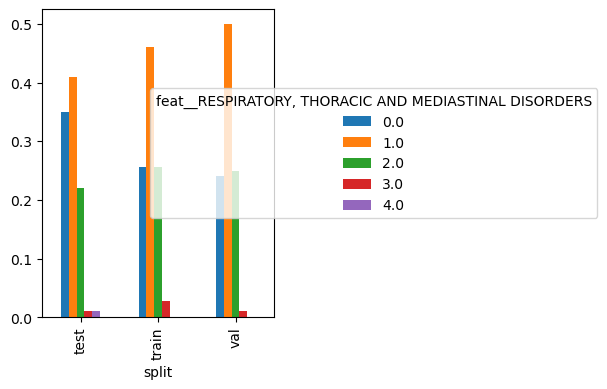

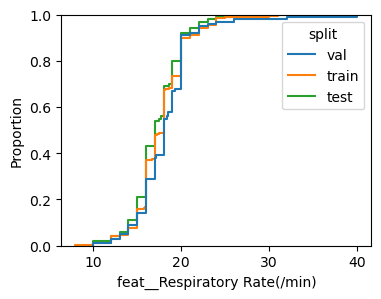

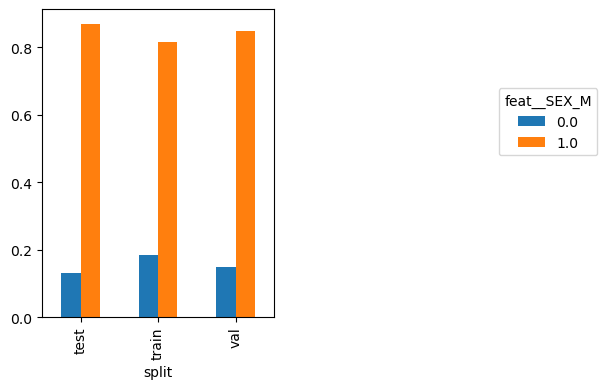

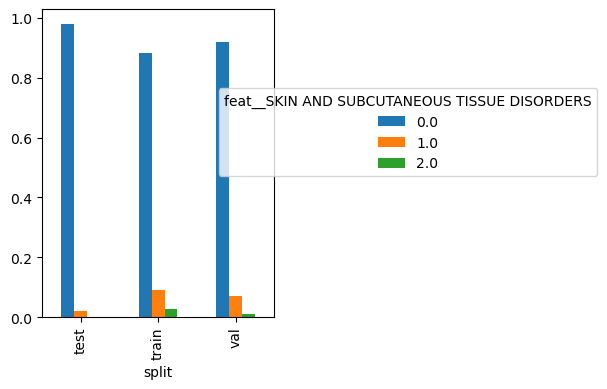

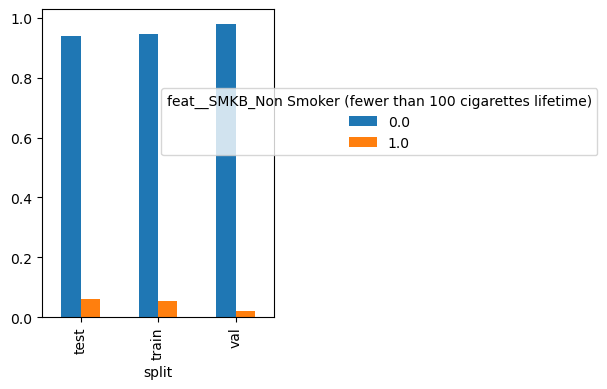

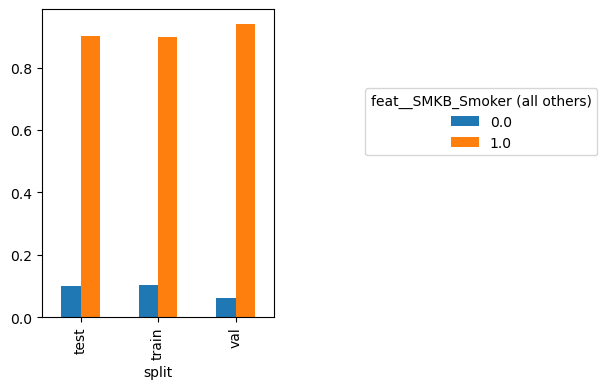

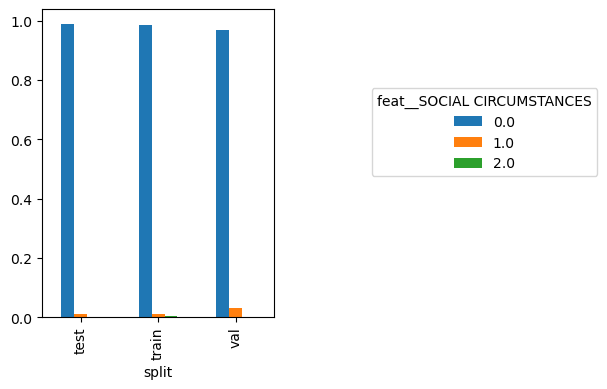

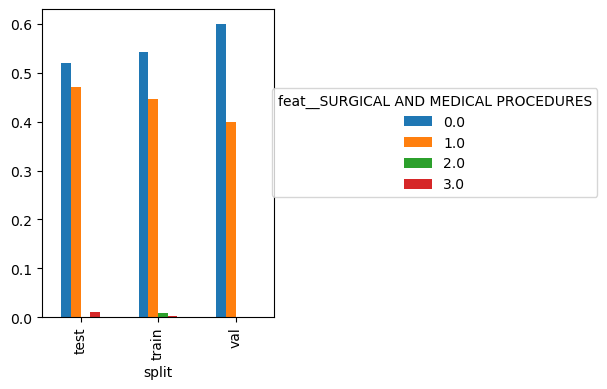

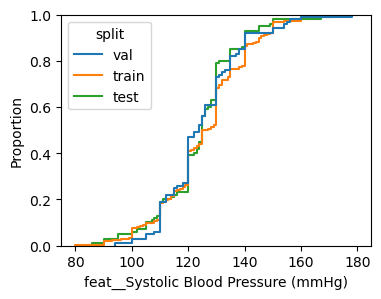

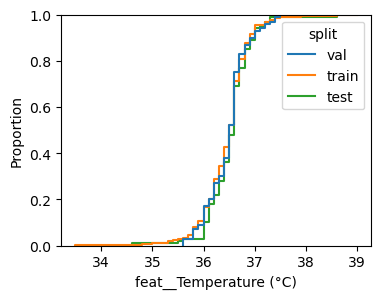

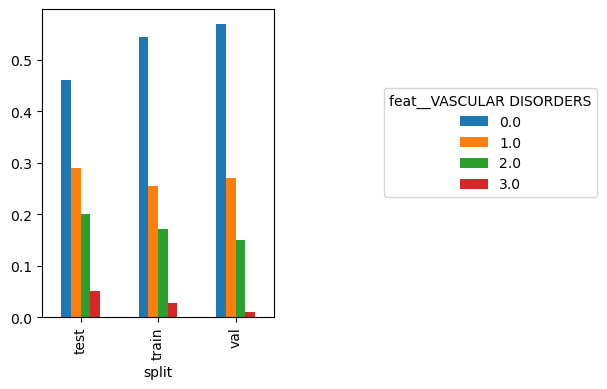

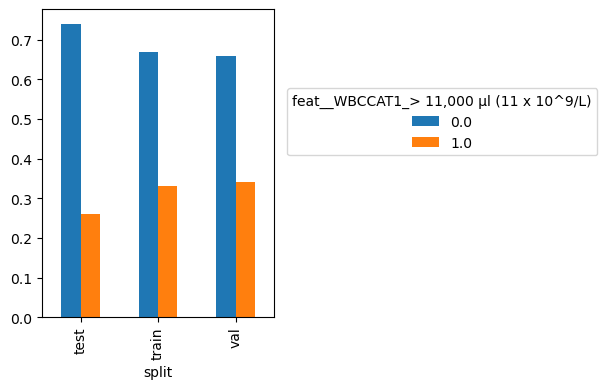

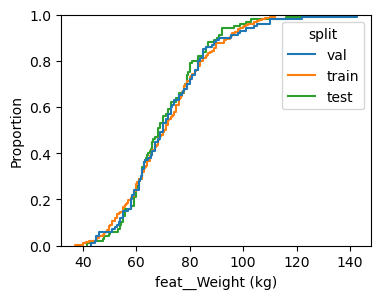

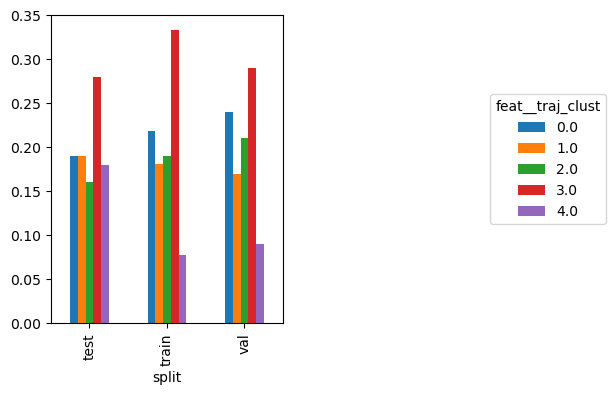

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in cols_feats:
    if df_features[col].nunique() > 5:
        fig, ax = plt.subplots(1,1, figsize=(4, 3))
        sns.ecdfplot(
            data=df_features_train_test_val,
            x=col,
            hue='split',
            ax=ax
        )
    else:
        df = pd.crosstab(
            df_features_train_test_val[col],
            df_features_train_test_val['split'],
        )
        df = (df/df.sum()).T
        fig, ax = plt.subplots(1,1, figsize=(3,4))
        df.plot(kind='bar', ax=ax, legend=False)

        fig.legend(bbox_to_anchor=(2, 0.7), title=col)

In [17]:
df_event_time

,subject,t,g_max_by_time
0,b'001-7881',0.0,0.0
1,b'001-7881',15.0,2.0
2,b'001-7881',30.0,2.0
0,b'001-7882',0.0,0.0
1,b'001-7882',2.0,2.0
...,...,...,...
6,b'981-7886',63.0,3.0
7,b'981-7886',78.0,3.0
8,b'981-7886',90.0,3.0
9,b'981-7886',98.0,3.0


In [18]:
from sklearn.preprocessing import StandardScaler
for suffix, subj in [
    ('train', subj_train),
    ('tune', subj_train_tune),
    ('val', subj_val),
    ('test', subj_test)
]:
    print(f'n_subj in {suffix}:{len(subj)}')
    

    df_features_sub = df_features.loc[
        df_features['subject'].isin(subj),
        :
    ].copy()

    if suffix == 'train':
        transform = StandardScaler().fit(df_features_sub[col_numer])
        cols_cat_max = df_features_sub[col_cat].max()
    df_features_sub[col_numer] = transform.transform(df_features_sub[col_numer])
    df_features_sub[col_cat] = df_features_sub[col_cat]/cols_cat_max
    df_features_sub.to_csv(os.path.join(DIR_SPLIT_OUT, f'{dataset_name_dir}__df_features_{suffix}.csv'))
    print(f'subj feat df shape: {df_features_sub.shape}')

    df_event_time_sub = df_event_time.loc[
        df_event_time['subject'].isin(subj),
        :
    ]
    
    df_event_time_sub.to_csv(os.path.join(DIR_SPLIT_OUT, f'{dataset_name_dir}__df_state_history_sampled_max_{suffix}.csv'))
    print(f'subj traj df shape: {df_event_time_sub.shape}')

del df_event_time
del df_features_sub
del df_features


n_subj in train:321
subj feat df shape: (321, 53)
subj traj df shape: (2198, 3)
n_subj in tune:160
subj feat df shape: (160, 53)
subj traj df shape: (1087, 3)
n_subj in val:100
subj feat df shape: (100, 53)
subj traj df shape: (654, 3)
n_subj in test:100
subj feat df shape: (100, 53)
subj traj df shape: (665, 3)


In [19]:
len(col_numer) + len(col_cat)

52